# DEGs comparisons
I compared the DEGs identified from pairwise comparisons of isolated treatments in [DEGs_overlap.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/DEGs_overlap.ipynb), but I'm also interested in looking more closely at DEGs and compare across phase 1 and phase 2 oysters. 

I've hypothesized that younger oysters will be more plastic than older oysters, and so I would expect to see more DEGs in phase 1 oysters compared to phase 2.

## 1. load libraries

In [5]:
library(tidyverse)
library(RColorBrewer)
library(rtracklayer)

## 2. load csvs

#### gene info

In [6]:
gff <- as.data.frame(import('/project/pi_sarah_gignouxwolfsohn_uml_edu/Reference_genomes/Cvirginica_genome/new_cvir_genome/GCF_053477285.1_ASM5347728v1_genomic.gff'))
head(gff)

,seqnames,start,end,width,strand,source,type,score,phase,ID,⋯,for_remapping,gap_count,num_ident,num_mismatch,pct_coverage,pct_coverage_hiqual,pct_identity_gap,pct_identity_ungap,rank,Gap
,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<dbl>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,NC_136047.1,1,64991568,64991568,+,RefSeq,region,NA,NA,NC_136047.1:1..64991568,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,NC_136047.1,34876,71533,36658,+,Gnomon,gene,NA,NA,gene-LOC144621260,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,NC_136047.1,34876,71533,36658,+,Gnomon,mRNA,NA,NA,rna-XM_078464077.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,NC_136047.1,34876,35035,160,+,Gnomon,exon,NA,NA,exon-XM_078464077.1-1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,NC_136047.1,46195,46780,586,+,Gnomon,exon,NA,NA,exon-XM_078464077.1-2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,NC_136047.1,49378,50230,853,+,Gnomon,exon,NA,NA,exon-XM_078464077.1-3,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [7]:
colnames(gff)

[1] "seqnames"            "start"               "end"                
 [4] "width"               "strand"              "source"             
 [7] "type"                "score"               "phase"              
[10] "ID"                  "Dbxref"              "Name"               
[13] "chromosome"          "collected.by"        "collection.date"    
[16] "country"             "dev.stage"           "gbkey"              
[19] "genome"              "isolate"             "isolation.source"   
[22] "mol_type"            "tissue.type"         "description"        
[25] "gene"                "gene_biotype"        "Parent"             
[28] "experiment"          "model_evidence"      "product"            
[31] "transcript_id"       "protein_id"          "Note"               
[34] "anticodon"           "inference"           "pseudo"             
[37] "exception"           "transl_except"       "partial"            
[40] "start_range"         "end_range"           "Target"             
[43] "for_remapping"       "gap_count"           "num_ident"          
[46] "num_mismatch"        "pct_coverage"        "pct_coverage_hiqual"
[49] "pct_identity_gap"    "pct_identity_ungap"  "rank"               
[52] "Gap"

In [8]:
gene_names <- gff %>% 
select(gene, description) %>% 
na.omit()

head(gene_names)

,gene,description
,<chr>,<chr>
2,LOC144621260,protein O-mannosyl-transferase TMTC2-like
28,LOC144621269,uncharacterized LOC144621269
63,LOC111120925,mitochondrial amidoxime-reducing component 1-like
79,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)
82,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)
85,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)


### A. phase 1 oysters

In [9]:
# get list of files
p1.files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq',
    pattern = "^p1.*\\.csv$",
    full.names = TRUE
    )

head(p1.files)

names(p1.files) <- gsub('p1.', '', tools::file_path_sans_ext(basename(p1.files)))
p1.files <- lapply(p1.files, read.csv)
names(p1.files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv"        
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1.both_v_cont.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1.hyp_v_both.csv" 
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv" 
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv" 
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1.warm_v_both.csv"

[1] "vst"         "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm" 
[6] "warm_v_both" "warm_v_cont"

In [10]:
# remove vst file from list
p1.files$vst <- NULL

#### pull out DEGs

In [17]:
p1.deg <- lapply(p1.files, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05) %>%
    rename(X = 'Gene')
})


names(p1.deg)
head(p1.deg$both_v_cont)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111120925,191.44305,-4.896908,1.409344,8.354541e-06,0.003582926
2,LOC111103173,15.14959,4.218534,2.190562,7.946660e-05,0.015793180
3,LOC111105159,57.17908,-5.231786,2.548807,4.742151e-05,0.010936026
4,LOC111132252,110.19476,-2.652227,2.036381,2.797628e-04,0.035208785
5,LOC111137262,591.06709,3.700067,3.002875,2.185576e-04,0.029883595
6,LOC111105069,273.29807,-3.773655,2.837697,1.914828e-04,0.027102591


#### format df for plotting

In [18]:
p1.deg2 <- Map(
  function(df, name) {
    
    # add df name column
    df$pair <- name
    
    # DEG assignment based on LFC direction
    df$DEG_group <- ifelse(
      df$log2FoldChange > 0,
      toupper(substr(sub("_.*", "", df$pair), 1, 1)),
      toupper(substr(sub(".*_", "", df$pair), 1, 1))
    )

    # add phase 1 column
    df$phase <- 'Phase 1'
      
    df
  },
  p1.deg,
  names(p1.deg)
)

p1.deg2 <- lapply(p1.deg2, function(df) {
# select only the necessary columns
  select(df, c(Gene, log2FoldChange, padj, pair, DEG_group, phase))
})

head(p1.deg2$both_v_cont)

,Gene,log2FoldChange,padj,pair,DEG_group,phase
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111120925,-4.896908,0.003582926,both_v_cont,C,Phase 1
2,LOC111103173,4.218534,0.015793180,both_v_cont,B,Phase 1
3,LOC111105159,-5.231786,0.010936026,both_v_cont,C,Phase 1
4,LOC111132252,-2.652227,0.035208785,both_v_cont,C,Phase 1
5,LOC111137262,3.700067,0.029883595,both_v_cont,B,Phase 1
6,LOC111105069,-3.773655,0.027102591,both_v_cont,C,Phase 1


In [19]:
sapply(p1.deg2, nrow)

both_v_cont  hyp_v_both  hyp_v_cont  hyp_v_warm warm_v_both warm_v_cont 
        216         107          30          50          83          61

### B. phase 2 oysters

In [20]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs/DEG_bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs/DEG_bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs/DEG_bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs/DEG_bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs/DEG_bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/DEGs/DEG_bh_ch.csv"

In [21]:
names(files) <- gsub('DEG_', '', tools::file_path_sans_ext(basename(files)))
p2.files <- lapply(files, read.csv)
names(p2.files)

[1] "bb_cc"        "bc_bb"        "bc_cc"        "bc_hc"        "bc_wc"       
 [6] "bh_ch"        "bh_hh"        "bw_cw"        "bw_ww"        "cb_bb"       
[11] "cb_bc"        "cb_cc"        "cb_ch"        "cb_cw"        "ch_cc"       
[16] "ch_hc"        "cw_cc"        "cw_ch"        "cw_wc"        "hb_bb"       
[21] "hb_bh"        "hb_cb"        "hc_cc"        "hc_hh"        "hh_cc"       
[26] "hh_ch"        "vst_filtered" "wb_bb"        "wb_bw"        "wb_cb"       
[31] "wc_cc"        "wc_hc"        "wc_ww"        "wh_hw"        "ww_cc"       
[36] "ww_cw"

In [33]:
p2.files$vst_filtered <- NULL

#### pull out DEGs

In [34]:
p2.deg <- lapply(p2.files, function(df) {
  df %>%
    dplyr::select('Gene' = X, log2FoldChange, padj, pair, DEG_group) %>%
    mutate(phase = 'Phase 2')
})

In [36]:
head(p2.deg$bb_cc)

,Gene,log2FoldChange,padj,pair,DEG_group,phase
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111102506,1.339691,4.716118e-02,CC vs. BB,BB,Phase 2
2,LOC144622036,22.563229,1.450507e-07,CC vs. BB,BB,Phase 2
3,LOC144619234,20.963235,1.088996e-08,CC vs. BB,BB,Phase 2
4,LOC144622046,20.425457,3.528692e-07,CC vs. BB,BB,Phase 2
5,LOC111105159,7.603607,4.134536e-03,CC vs. BB,BB,Phase 2
6,LOC144622060,22.076677,1.507335e-09,CC vs. BB,BB,Phase 2


In [35]:
sapply(p2.deg, nrow)

bb_cc bc_bb bc_cc bc_hc bc_wc bh_ch bh_hh bw_cw bw_ww cb_bb cb_bc cb_cc cb_ch 
  306   204   281   134   194   222   222   123   118    78   169   243   138 
cb_cw ch_cc ch_hc cw_cc cw_ch cw_wc hb_bb hb_bh hb_cb hc_cc hc_hh hh_cc hh_ch 
  123   185    86   428   122    87    92   273    78   145   175   186   191 
wb_bb wb_bw wb_cb wc_cc wc_hc wc_ww wh_hw ww_cc ww_cw 
   54   255   199   167    83    78    89   343    47

### C. merge dfs for plotting

In [37]:
deg.all <- bind_rows(c(p1.deg2, p2.deg))
head(deg.all)

,Gene,log2FoldChange,padj,pair,DEG_group,phase
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111120925,-4.896908,0.003582926,both_v_cont,C,Phase 1
2,LOC111103173,4.218534,0.015793180,both_v_cont,B,Phase 1
3,LOC111105159,-5.231786,0.010936026,both_v_cont,C,Phase 1
4,LOC111132252,-2.652227,0.035208785,both_v_cont,C,Phase 1
5,LOC111137262,3.700067,0.029883595,both_v_cont,B,Phase 1
6,LOC111105069,-3.773655,0.027102591,both_v_cont,C,Phase 1


In [45]:
tail(deg.all)

,Gene,log2FoldChange,padj,pair,DEG_group,phase,phase1_DEGletter
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
6460,LOC111121246,-6.914382,1.372451e-03,CW vs. WW,CW,Phase 2,C
6461,LOC144621682,9.951844,1.337112e-02,CW vs. WW,WW,Phase 2,W
6462,LOC144621807,-48.300970,7.881210e-72,CW vs. WW,CW,Phase 2,C
6463,LOC111114643,16.247786,1.951926e-05,CW vs. WW,WW,Phase 2,W
6464,LOC144621318,-44.784457,2.902052e-19,CW vs. WW,CW,Phase 2,C
6465,LOC111111765,-18.867721,1.607290e-06,CW vs. WW,CW,Phase 2,C


## 3. plot DEGs per comparison

### barplot of all DEGs


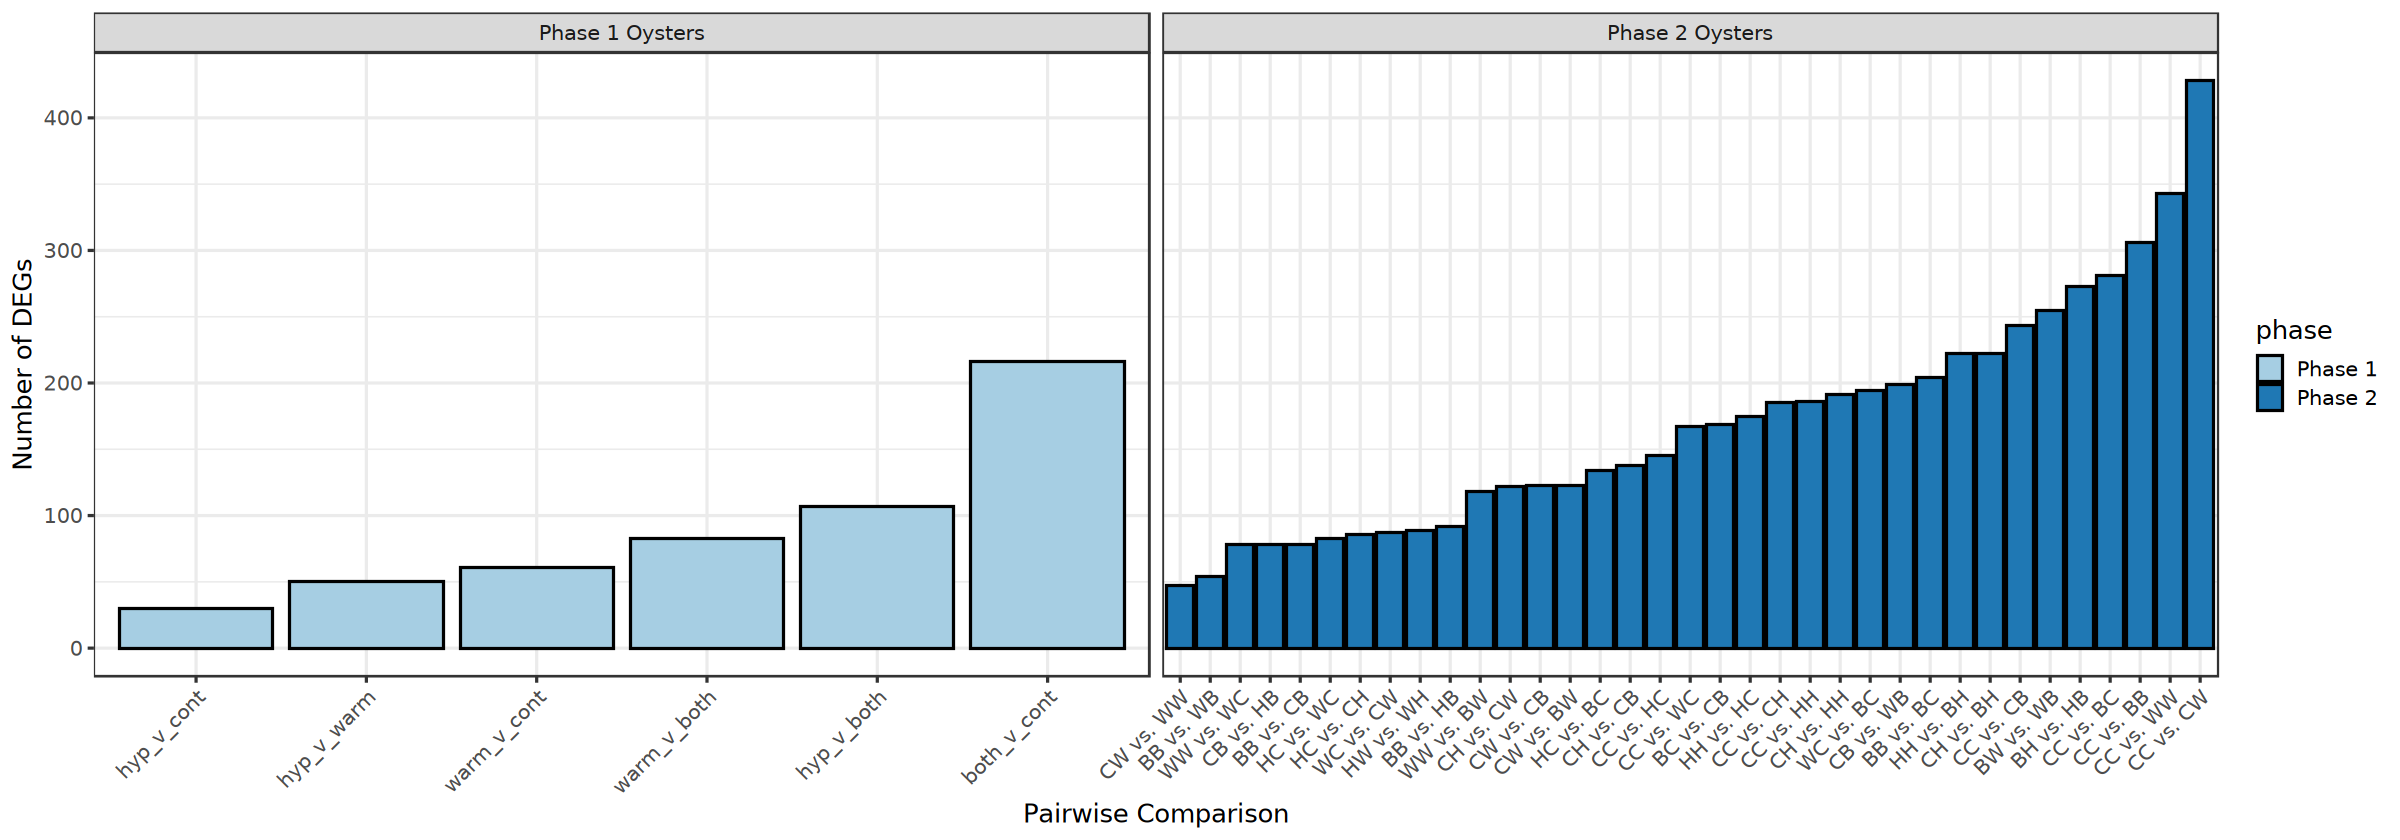

In [38]:
options(repr.plot.height = 7, repr.plot.width = 20)

facet_labels <- c('Phase 1' = 'Phase 1 Oysters',
                  'Phase 2' = 'Phase 2 Oysters')

deg.all <- deg.all %>%
  mutate(phase1_DEGletter = substr(DEG_group, 1, 1))

ggplot(deg.all, aes(x = fct_rev(fct_infreq(pair)), fill = phase)) +
  geom_bar(stat = "count", col = 'black') +
  facet_wrap(~ phase, scales = "free_x", labeller = labeller(phase = facet_labels)) +
  theme_bw(base_size = 15) +
scale_fill_brewer(palette = 'Paired') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(x = 'Pairwise Comparison',
     y = 'Number of DEGs')


it looks like overall, there are less DEGs in the phase 1 samples compared to the phase 2 samples but I haven't statistically tested this yet

**phase 1**: the comparisons with the most DEGs are those with oysters that experienced both stressors (which makes sense - maybe an additive or interactive effect of the two stressors) - but looks like most of the time the genes are downregulated in both (so higher expression in the other treatment)

**phase 2**: looks similar to phase 1 in that we see more purple (comparisons with phase 1 both) in the comparisons with the majority of DEGs

in thinking about theory - transcriptional plasticity may be limited at the earlier age bc they might be experiencing this stressor for the first time, and so they don't know what to do about it yet (they don't know if this is a reliable cue? maybe the cost of being plastic is really high at that age?) vs. later, if they're experiencing the/a stressor again, this might be seen as a reliable cue now (or just informative!) and/or this is not a critical developmental window and so they can be more plastic ??

In [39]:
deg.all %>%
count(pair, phase) %>%
  group_by(phase) %>%
  summarise(
    min_n = min(n, na.rm = TRUE),
    max_n = max(n, na.rm = TRUE)
  )

phase,min_n,max_n
<chr>,<int>,<int>
Phase 1,30,216
Phase 2,47,428


## 4. young vs. old oysters - plastic?
The above plot cannot be used to ask if younger oysters are more plastic than older, because there are more pairwise comparisons in phase 2 oysters (32 compared to 6 in phase 1) and the phase 2 oysters have more complex histories. 

So, to navigate around this, I'm only going to pull the phase 2 samples that experienced control conditions early in life (i.e., CC, CW, CB, CH)

In [48]:
unique(deg.all$pair)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
 [6] "warm_v_cont" "CC vs. BB"   "BB vs. BC"   "CC vs. BC"   "HC vs. BC"  
[11] "WC vs. BC"   "CH vs. BH"   "HH vs. BH"   "CW vs. BW"   "WW vs. BW"  
[16] "BB vs. CB"   "BC vs. CB"   "CC vs. CB"   "CH vs. CB"   "CW vs. CB"  
[21] "CC vs. CH"   "HC vs. CH"   "CC vs. CW"   "CH vs. CW"   "WC vs. CW"  
[26] "BB vs. HB"   "BH vs. HB"   "CB vs. HB"   "CC vs. HC"   "HH vs. HC"  
[31] "CC vs. HH"   "CH vs. HH"   "BB vs. WB"   "BW vs. WB"   "CB vs. WB"  
[36] "CC vs. WC"   "HC vs. WC"   "WW vs. WC"   "HW vs. WH"   "CC vs. WW"  
[41] "CW vs. WW"

In [49]:
deg.subset <- deg.all %>% 
filter(phase == 'Phase 1' | pair %in% c('CC vs. CB', 'CC vs. CW', 'CC vs. CH', 
                                             'CW vs. CB', 'CH vs. CB', 'CH vs. CW'))

head(deg.subset)
unique(deg.subset$pair)

,Gene,log2FoldChange,padj,pair,DEG_group,phase,phase1_DEGletter
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,LOC111120925,-4.896908,0.003582926,both_v_cont,C,Phase 1,C
2,LOC111103173,4.218534,0.015793180,both_v_cont,B,Phase 1,B
3,LOC111105159,-5.231786,0.010936026,both_v_cont,C,Phase 1,C
4,LOC111132252,-2.652227,0.035208785,both_v_cont,C,Phase 1,C
5,LOC111137262,3.700067,0.029883595,both_v_cont,B,Phase 1,B
6,LOC111105069,-3.773655,0.027102591,both_v_cont,C,Phase 1,C


[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
 [6] "warm_v_cont" "CC vs. CB"   "CH vs. CB"   "CW vs. CB"   "CC vs. CH"  
[11] "CC vs. CW"   "CH vs. CW"

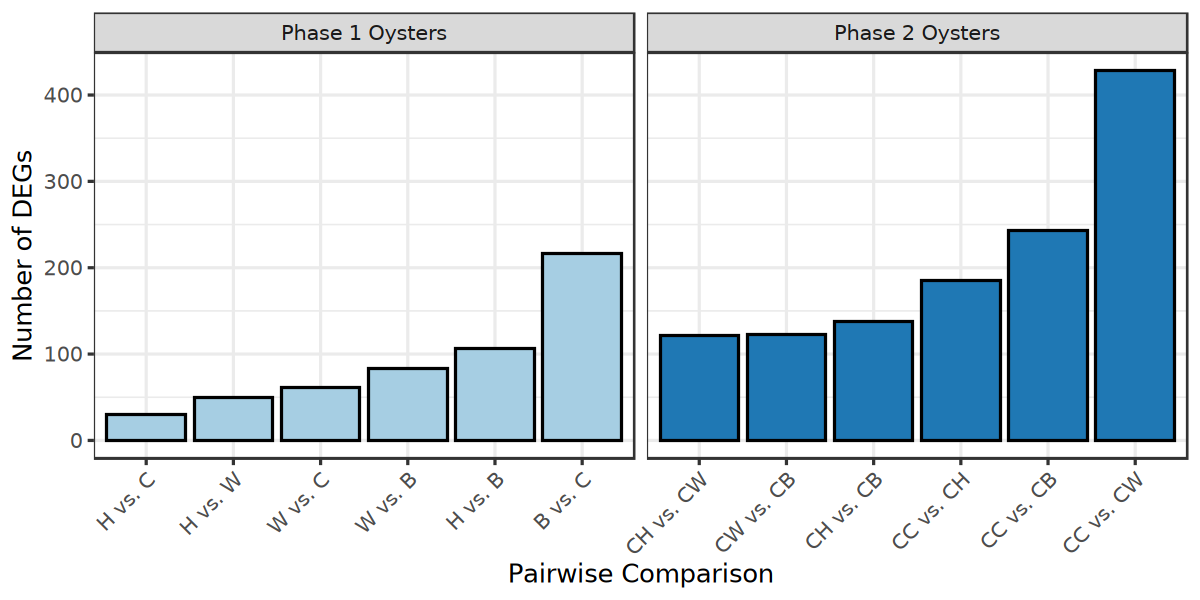

In [51]:
options(repr.plot.height = 5, repr.plot.width = 10)

facet_labels <- c('Phase 1' = 'Phase 1 Oysters',
                  'Phase 2' = 'Phase 2 Oysters')

ggplot(deg.subset, aes(x = fct_rev(fct_infreq(pair)), fill = phase)) +
  geom_bar(stat = "count", col = 'black') +
  facet_wrap(~ phase, scales = "free_x", labeller = labeller(phase = facet_labels)) +
  theme_bw(base_size = 15) +
scale_fill_brewer(palette = 'Paired') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(x = 'Pairwise Comparison',
     y = 'Number of DEGs') +
scale_x_discrete(labels = c(
    hyp_v_cont = "H vs. C",
    hyp_v_warm = "H vs. W",
    warm_v_cont = "W vs. C",
    warm_v_both = 'W vs. B',
    hyp_v_both = 'H vs. B',
    both_v_cont = 'B vs. C'
  )) +
guides(fill = 'none')

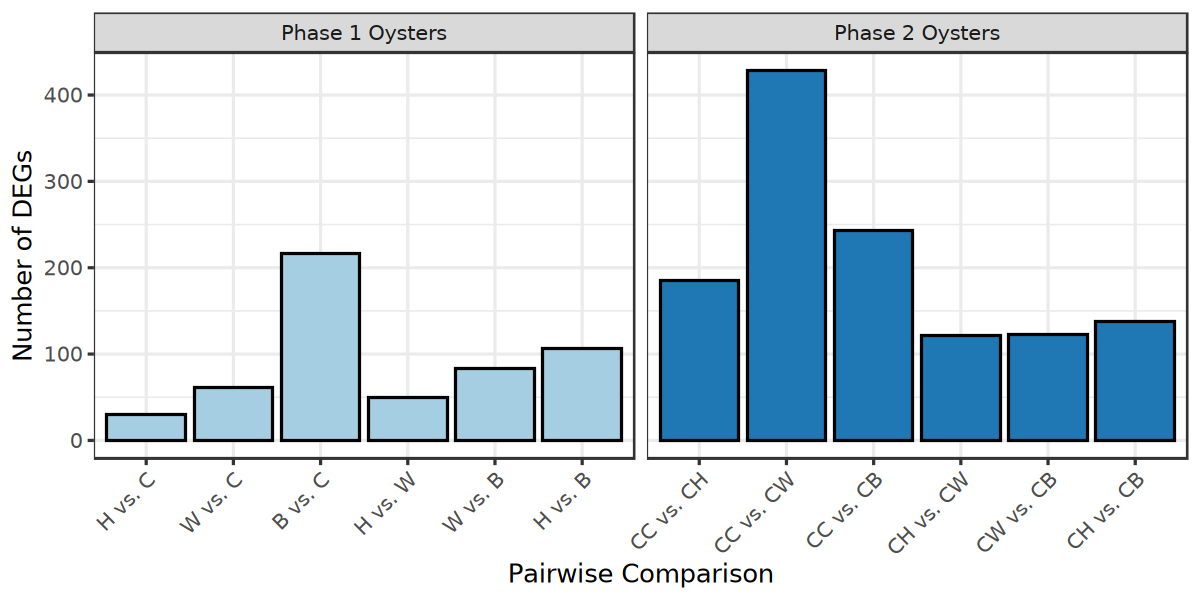

In [52]:
options(repr.plot.height = 5, repr.plot.width = 10)

facet_labels <- c('Phase 1' = 'Phase 1 Oysters',
                  'Phase 2' = 'Phase 2 Oysters')

deg.subset$pair <- factor(deg.subset$pair, levels = c('hyp_v_cont',
                                     'warm_v_cont', 
                                     'both_v_cont',
                                     'hyp_v_warm', 
                                     'warm_v_both', 
                                     'hyp_v_both', 
                                     'CC vs. CH',
                                     'CC vs. CW',
                                     'CC vs. CB',
                                     'CH vs. CW',
                                     'CW vs. CB',
                                     'CH vs. CB'))

ggplot(deg.subset, aes(x = pair, fill = phase)) +
  geom_bar(stat = "count", col = 'black') +
  facet_wrap(~ phase, scales = "free_x", labeller = labeller(phase = facet_labels)) +
  theme_bw(base_size = 15) +
scale_fill_brewer(palette = 'Paired') +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(x = 'Pairwise Comparison',
     y = 'Number of DEGs') +
scale_x_discrete(labels = c(
    hyp_v_cont = "H vs. C",
    hyp_v_warm = "H vs. W",
    warm_v_cont = "W vs. C",
    warm_v_both = 'W vs. B',
    hyp_v_both = 'H vs. B',
    both_v_cont = 'B vs. C'
  )) +
guides(fill = 'none')

### boxplot of number of DEGs

In [53]:
# count the number of DEGs per comparison
deg.count <- deg.subset %>%
count(pair, phase)

head(deg.count)

,pair,phase,n
,<fct>,<chr>,<int>
1,hyp_v_cont,Phase 1,30
2,warm_v_cont,Phase 1,61
3,both_v_cont,Phase 1,216
4,hyp_v_warm,Phase 1,50
5,warm_v_both,Phase 1,83
6,hyp_v_both,Phase 1,107


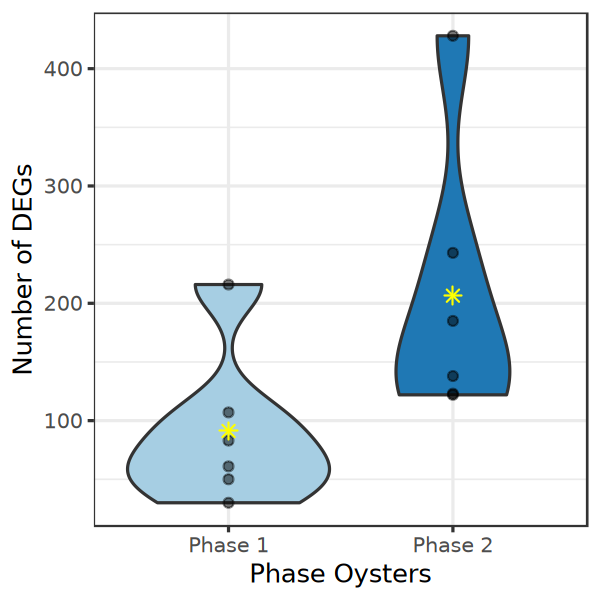

In [57]:
options(repr.plot.width = 5, repr.plot.height = 5)

ggplot(deg.count, aes(x = phase, y = n, fill = phase)) +
geom_violin() +
geom_point(alpha = 0.5) +
stat_summary(
    position = position_dodge(width = 0.75),
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
theme_bw(base_size = 15) +
scale_fill_brewer(palette = 'Paired') +
theme(legend.position = 'none') +
labs(x = 'Phase Oysters',
    y = 'Number of DEGs')

In [59]:
deg.aov <- aov(n ~ phase, data = deg.count)
summary(deg.aov)

            Df Sum Sq Mean Sq F value Pr(>F)  
phase        1  39905   39905   4.342 0.0638 .
Residuals   10  91908    9191                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

only slightly more DEGs in phase 2 oysters but not that much

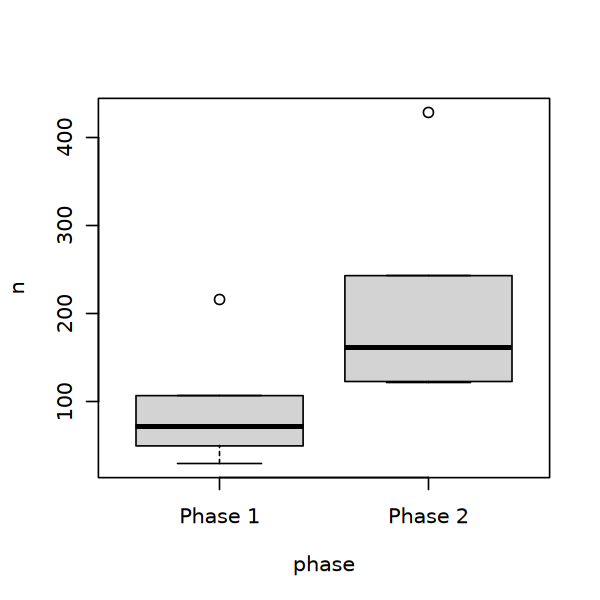

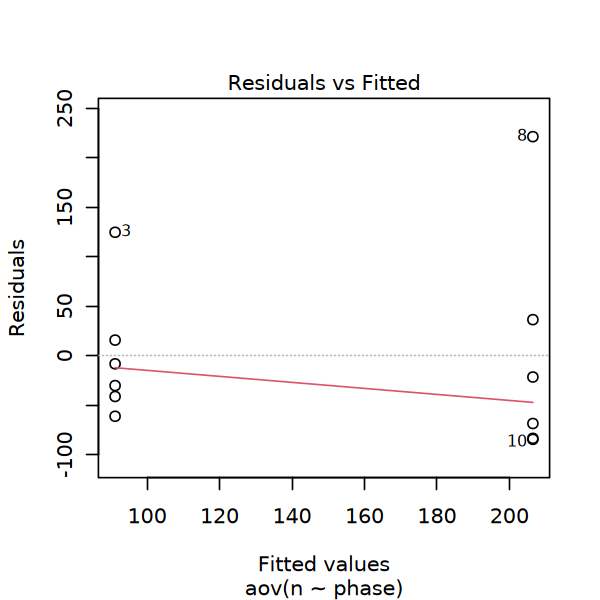

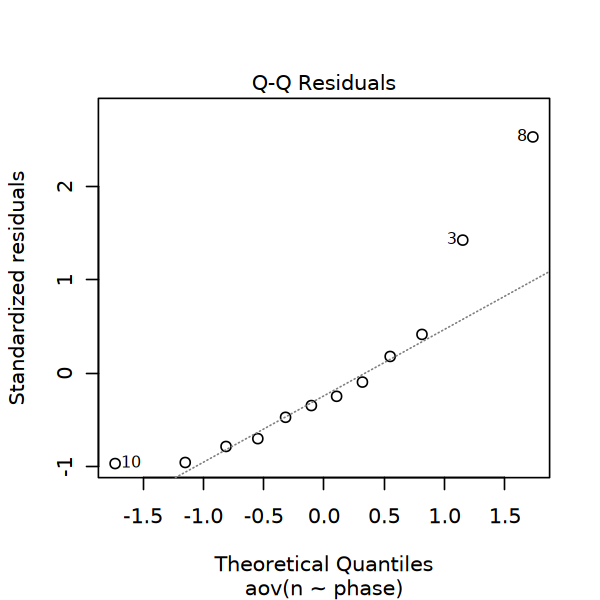

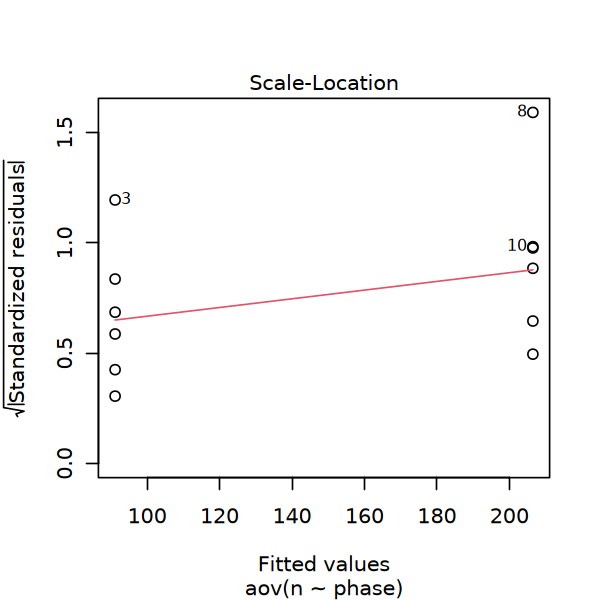

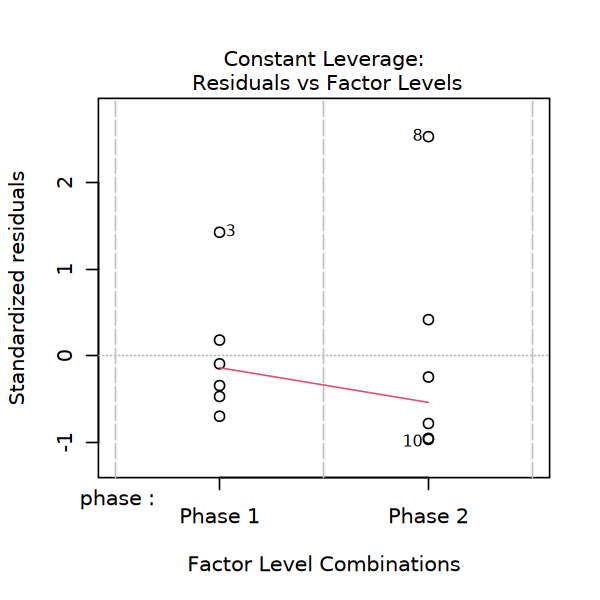

In [60]:
boxplot(n ~ phase, data = deg.count)

plot(deg.aov)

check residuals:

In [61]:
shapiro.test(residuals(deg.aov))


	Shapiro-Wilk normality test

data:  residuals(deg.aov)
W = 0.83468, p-value = 0.02387


reject the Shapiro-Wilk null hypothesis of normality due to significant pvalue - so the data is not normally distributed, which violates one of the ANOVA assumptions

check variance differences:

In [62]:
car::leveneTest(n ~ phase, data = deg.count)

Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,1,0.6295308,0.4459453
,10,NA,NA


so we have equal variances among phase 1 and 2 groups

In [65]:
deg.count %>%
  group_by(phase) %>%
  summarise(
    min_n = min(n, na.rm = TRUE),
    max_n = max(n, na.rm = TRUE)
  )

phase,min_n,max_n
<chr>,<int>,<int>
Phase 1,30,216
Phase 2,122,428


## 5. plot phase 1 oysters DEGs

wanting to look at only comparisons with control to pick out upregulated and downregulated DEGs, similar to the phase 2 comparison I did in [this notebook](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/upset_p2.v.p2.ipynb)

In [66]:
p1.df <- deg.all %>% filter(phase == 'Phase 1')
head(p1.df)

,Gene,log2FoldChange,padj,pair,DEG_group,phase,phase1_DEGletter
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,LOC111120925,-4.896908,0.003582926,both_v_cont,C,Phase 1,C
2,LOC111103173,4.218534,0.015793180,both_v_cont,B,Phase 1,B
3,LOC111105159,-5.231786,0.010936026,both_v_cont,C,Phase 1,C
4,LOC111132252,-2.652227,0.035208785,both_v_cont,C,Phase 1,C
5,LOC111137262,3.700067,0.029883595,both_v_cont,B,Phase 1,B
6,LOC111105069,-3.773655,0.027102591,both_v_cont,C,Phase 1,C


In [67]:
p1_vs.c <- deg.all[grepl('cont', deg.all$pair),] %>%
# denote up- or down-regulated compared to control
mutate(direction = case_when(
DEG_group == 'C' ~ 'downregulated',
    .default = 'upregulated'))
head(p1_vs.c)

,Gene,log2FoldChange,padj,pair,DEG_group,phase,phase1_DEGletter,direction
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,LOC111120925,-4.896908,0.003582926,both_v_cont,C,Phase 1,C,downregulated
2,LOC111103173,4.218534,0.015793180,both_v_cont,B,Phase 1,B,upregulated
3,LOC111105159,-5.231786,0.010936026,both_v_cont,C,Phase 1,C,downregulated
4,LOC111132252,-2.652227,0.035208785,both_v_cont,C,Phase 1,C,downregulated
5,LOC111137262,3.700067,0.029883595,both_v_cont,B,Phase 1,B,upregulated
6,LOC111105069,-3.773655,0.027102591,both_v_cont,C,Phase 1,C,downregulated


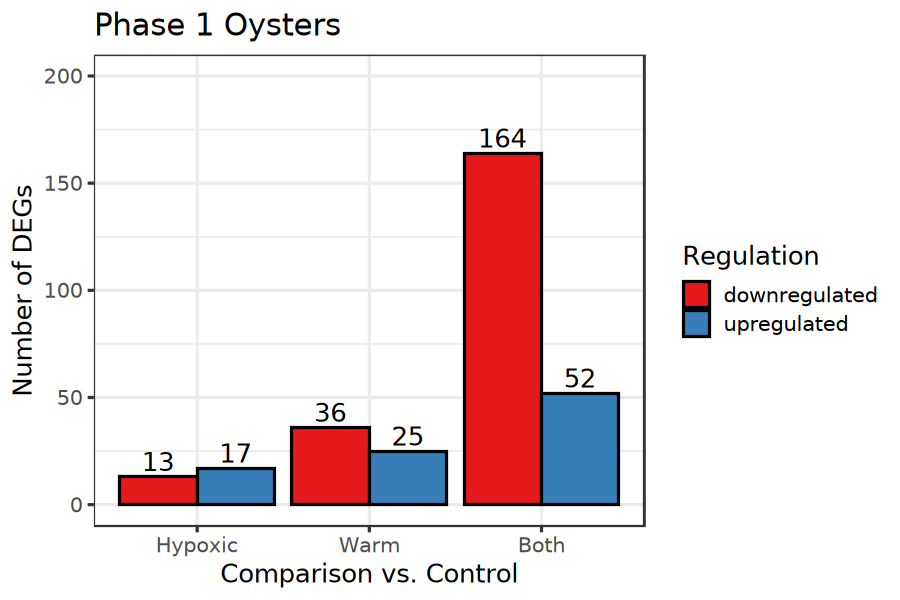

In [68]:
options(repr.plot.height = 5, repr.plot.width = 7.5) 

ggplot(p1_vs.c, aes(x = fct_rev(fct_infreq(pair)), fill = direction)) +
geom_bar(stat = 'count', col = 'black', position = 'dodge') +
scale_fill_brewer(palette = 'Set1') +
geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    position = position_dodge(width = 0.9),
    vjust = -0.3
  ) +
ylim(0, 200) +
scale_x_discrete(labels = c('hyp_v_cont' = 'Hypoxic',
                            'warm_v_cont' = 'Warm',
                            'both_v_cont' = 'Both')) +
labs(x = 'Comparison vs. Control',
    y = 'Number of DEGs',
    fill = 'Regulation',
    title = 'Phase 1 Oysters') +
theme_bw(base_size = 15)

similar to phase 2, most DEGs are downregulated in comparison to control conditions

to see what pathways/processes are significantly enriched in these comparisons, see [GO_newRef_p1.v.p1.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/new_refGenome/GO_newRef_p1.v.p1.ipynb)